# Numerical Simulation of 1D Heat Diffusion

This notebook develops a numerical simulation of transient heat diffusion in a one-dimensional rod using the FTCS finite-difference method.

Unlike the introductory five-point example, this simulation uses:

- a physically defined rod length
- a realistic spatial grid
- thermal diffusivity
- a stable time step calculated from the FTCS stability condition
- a smooth initial temperature distribution
- physical time rather than arbitrary iteration numbers

The numerical model developed here will later be used to generate synthetic sensor measurements for the Scientific Machine Learning and Physics-Informed Neural Network stages of the project.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Physical System

We consider a one-dimensional rod of length:

$$
L = 1 \text{ m}
$$

The temperature is represented by the field:

$$
T(x,t)
$$

and evolves according to the one-dimensional heat equation:

$$
\frac{\partial T}{\partial t}
=
\alpha
\frac{\partial^2T}{\partial x^2}
$$

where $\alpha$ is the thermal diffusivity.

The rod is initially at approximately $20^\circ C$, except for a hotter region near its center.

After the initial condition is defined, no additional heat is supplied to the rod.

The temperatures at both ends are maintained at:

$$
20^\circ C
$$

throughout the simulation.

## 2. Spatial Discretization

The continuous rod is divided into a finite number of spatial grid points.

Let:

$$
N_x = 51
$$

be the number of grid points.

The spatial grid spacing is therefore:

$$
\Delta x
=
\frac{L}{N_x-1}
$$

A finer spatial grid allows the temperature field to be represented more accurately than the five-point example used previously.

In [2]:
L = 1.0
nx = 51

x = np.linspace(0, L, nx)

dx = x[1] - x[0]

print("Rod length:", L, "m")
print("Number of grid points:", nx)
print("Spatial step dx:", dx, "m")

Rod length: 1.0 m
Number of grid points: 51
Spatial step dx: 0.02 m


## 3. Thermal Diffusivity

The rate at which temperature disturbances spread through the material is controlled by the thermal diffusivity:

$$
\alpha
$$

For this simulation, we use:

$$
\alpha = 1.0\times10^{-4}\text{ m}^2/\text{s}
$$

This value provides a physically reasonable order of magnitude for a thermally conductive solid and is sufficient for studying the numerical and machine-learning aspects of the problem.

Thermal diffusivity relates thermal conductivity, density, and specific heat capacity through:

$$
\alpha
=
\frac{k}{\rho c_p}
$$

In [3]:
alpha = 1.0e-4

print("Thermal diffusivity:", alpha, "m²/s")

Thermal diffusivity: 0.0001 m²/s


## 4. Time Step and Numerical Stability

For the explicit FTCS method, numerical stability requires:

$$
r
=
\frac{\alpha\Delta t}{\Delta x^2}
\leq 0.5
$$

Therefore, the maximum stable time step is:

$$
\Delta t_{\max}
=
\frac{\Delta x^2}{2\alpha}
$$

Rather than using the exact stability limit, the simulation uses a slightly smaller time step for additional numerical safety.

We choose:

$$
\Delta t
=
0.9\,\Delta t_{\max}
$$

which corresponds to a diffusion number of approximately:

$$
r=0.45
$$

In [4]:
dt_max = dx**2 / (2 * alpha)

dt = 0.9 * dt_max

r = alpha * dt / dx**2

print("Maximum stable dt:", dt_max, "s")
print("Chosen dt:", dt, "s")
print("Diffusion number r:", r)

Maximum stable dt: 2.0 s
Chosen dt: 1.8 s
Diffusion number r: 0.45


## 5. Initial Temperature Distribution

The rod is initially close to an ambient temperature of:

$$
T_{\text{ambient}} = 20^\circ C
$$

A localized hot region is placed at the center of the rod.

The initial temperature profile is represented by a Gaussian function:

$$
T(x,0)
=
T_{\text{ambient}}
+
A
\exp
\left(
-\frac{(x-x_c)^2}{2\sigma^2}
\right)
$$

where:

- $T_{\text{ambient}}$ is the background temperature
- $A$ determines the temperature increase at the center
- $x_c$ defines the location of the hot spot
- $\sigma$ controls the width of the hot region

For this simulation, the hot region is centered at:

$$
x_c = 0.5 \text{ m}
$$

In [5]:
T_ambient = 20.0
A = 80.0
x_center = 0.5
sigma = 0.08

In [6]:
T = T_ambient + A * np.exp(
    -((x - x_center)**2) / (2 * sigma**2)
)

In [7]:
print("Minimum temperature:", T.min())
print("Maximum temperature:", T.max())
print("Center temperature:", T[nx // 2])

Minimum temperature: 20.000000263497128
Maximum temperature: 100.0
Center temperature: 100.0


## 6. Visualizing the Initial Condition

Before solving the heat equation, the initial temperature distribution is visualized to verify that the chosen mathematical model represents the intended physical system.

The expected profile contains a smooth temperature peak near the center of the rod and approaches the ambient temperature toward both ends.

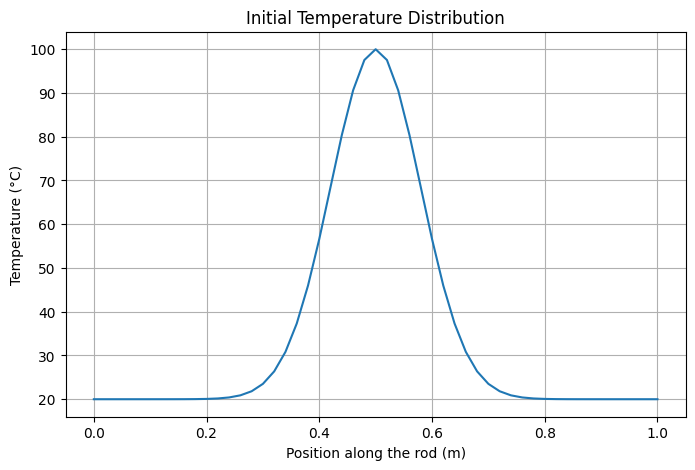

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(x, T)

plt.xlabel("Position along the rod (m)")
plt.ylabel("Temperature (°C)")
plt.title("Initial Temperature Distribution")

plt.grid()
plt.show()

## 7. Solving the Heat Equation Through Time

The initial temperature field represents the system at:

$$
t = 0
$$

To calculate how the temperature evolves, the FTCS update equation is applied repeatedly:

$$
T_i^{n+1}
=
T_i^n
+
r
\left(
T_{i+1}^n
-
2T_i^n
+
T_{i-1}^n
\right)
$$

where:

$$
r =
\frac{\alpha \Delta t}{\Delta x^2}
$$

The temperatures at the two boundaries remain fixed at:

$$
20^\circ C
$$

throughout the simulation.

In [9]:
T[0] = T_ambient
T[-1] = T_ambient

print(T[0], T[-1])

20.0 20.0


## 8. Simulation Time

The system is simulated for a total physical time of:

$$
t_{\text{final}} = 200 \text{ s}
$$

Because the numerical time step is $\Delta t$, the required number of time steps is:

$$
N_t
=
\frac{t_{\text{final}}}{\Delta t}
$$

The temperature field at each time step is stored so that the evolution of the system can later be analyzed and visualized.

In [10]:
t_final = 200.0

n_steps = int(t_final / dt)

print("Time step dt:", dt, "s")
print("Number of time steps:", n_steps)

Time step dt: 1.8 s
Number of time steps: 111


In [11]:
T_current = T.copy()

history = [T_current.copy()]

for n in range(n_steps):

    T_new = T_current.copy()

    for i in range(1, nx - 1):

        T_new[i] = (
            T_current[i]
            + r * (
                T_current[i + 1]
                - 2 * T_current[i]
                + T_current[i - 1]
            )
        )

    # Fixed-temperature boundaries
    T_new[0] = T_ambient
    T_new[-1] = T_ambient

    T_current = T_new

    history.append(T_current.copy())

In [12]:
history = np.array(history)

print(history.shape)

(112, 51)


In [13]:
time = np.arange(len(history)) * dt

print("Initial time:", time[0])
print("Final stored time:", time[-1])

Initial time: 0.0
Final stored time: 199.8


## 9. Temperature Profiles at Selected Times

To observe how the temperature field evolves, the temperature distribution is plotted at several physical times.

The initial sharp temperature peak should gradually decrease and spread outward as heat diffuses through the rod.

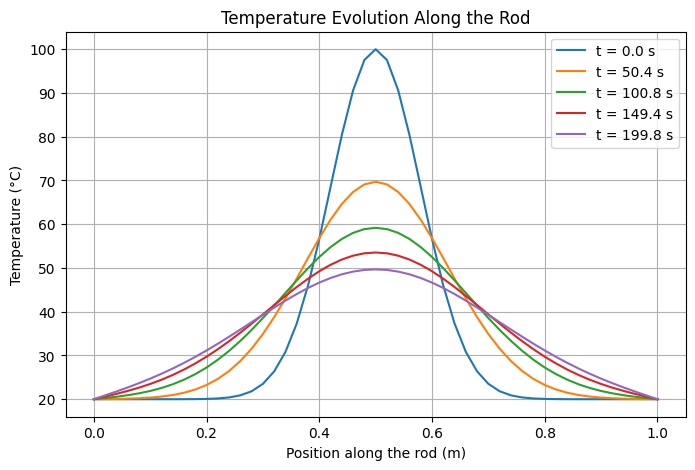

In [14]:
selected_times = [0, 50, 100, 150, 200]

plt.figure(figsize=(8, 5))

for t_target in selected_times:
    idx = np.argmin(np.abs(time - t_target))

    plt.plot(
        x,
        history[idx],
        label=f"t = {time[idx]:.1f} s"
    )

plt.xlabel("Position along the rod (m)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Evolution Along the Rod")
plt.legend()
plt.grid()
plt.show()

## 10. Space-Time Temperature Field

The previous plots show the temperature profile at selected moments in time.

To visualize the complete evolution of the system, the temperature field is represented as a two-dimensional heatmap:

$$
T(x,t)
$$

where:

- the horizontal axis represents position along the rod
- the vertical axis represents time
- the color represents temperature

This visualization makes it possible to observe how the initial hot region spreads and weakens over time.

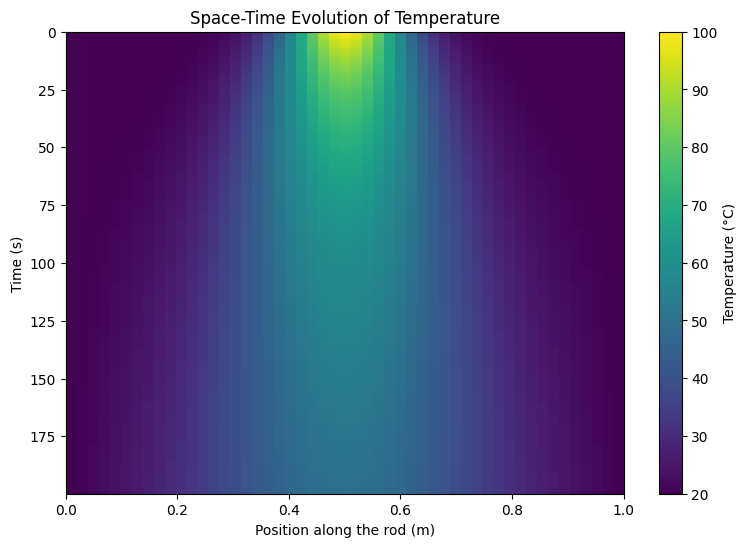

In [15]:
plt.figure(figsize=(9, 6))

plt.imshow(
    history,
    extent=[x.min(), x.max(), time.max(), time.min()],
    aspect="auto"
)

plt.colorbar(label="Temperature (°C)")

plt.xlabel("Position along the rod (m)")
plt.ylabel("Time (s)")
plt.title("Space-Time Evolution of Temperature")

plt.show()

## 11. Grid-Convergence Study

A numerical solution should not depend strongly on the particular grid used.

To test the reliability of the finite-difference solver, the same physical problem is solved using increasingly fine spatial grids.

We use:

$$
N_x = 21,\ 41,\ 81
$$

As the number of grid points increases, the spatial spacing

$$
\Delta x
$$

becomes smaller.

For each grid, the time step is recalculated so that the diffusion number remains safely below the FTCS stability limit:

$$
r =
\frac{\alpha \Delta t}{\Delta x^2}
\leq 0.5
$$

If the numerical method is converging, the solutions from the finer grids should become increasingly similar.

In [16]:
def simulate_heat(nx, t_final=200.0, alpha=1.0e-4, r_target=0.45):

    # Spatial grid
    L = 1.0
    x = np.linspace(0, L, nx)
    dx = x[1] - x[0]

    # Stable time step
    dt_target = r_target * dx**2 / alpha

    # Choose an integer number of steps so that
    # the simulation ends exactly at t_final
    n_steps = int(np.ceil(t_final / dt_target))

    dt = t_final / n_steps

    # Actual diffusion number
    r = alpha * dt / dx**2

    # Initial Gaussian temperature profile
    T_ambient = 20.0
    A = 80.0
    x_center = 0.5
    sigma = 0.08

    T = T_ambient + A * np.exp(
        -((x - x_center)**2) / (2 * sigma**2)
    )

    # Fixed boundary conditions
    T[0] = T_ambient
    T[-1] = T_ambient

    # Time integration
    for n in range(n_steps):

        T_new = T.copy()

        for i in range(1, nx - 1):
            T_new[i] = (
                T[i]
                + r * (
                    T[i + 1]
                    - 2 * T[i]
                    + T[i - 1]
                )
            )

        T_new[0] = T_ambient
        T_new[-1] = T_ambient

        T = T_new

    return x, T, dx, dt, r

In [17]:
grid_sizes = [21, 41, 81]

results = {}

for nx_test in grid_sizes:

    x_test, T_test, dx_test, dt_test, r_test = simulate_heat(nx_test)

    results[nx_test] = {
        "x": x_test,
        "T": T_test,
        "dx": dx_test,
        "dt": dt_test,
        "r": r_test
    }

    print(
        f"nx = {nx_test:3d} | "
        f"dx = {dx_test:.5f} m | "
        f"dt = {dt_test:.5f} s | "
        f"r = {r_test:.4f} | "
        f"center T = {T_test[nx_test // 2]:.4f} °C"
    )

nx =  21 | dx = 0.05000 m | dt = 11.11111 s | r = 0.4444 | center T = 49.4222 °C
nx =  41 | dx = 0.02500 m | dt = 2.77778 s | r = 0.4444 | center T = 49.6384 °C
nx =  81 | dx = 0.01250 m | dt = 0.70175 s | r = 0.4491 | center T = 49.6918 °C


## 12. Comparing Grid Resolutions

The final temperature profiles obtained with different spatial resolutions are compared at the same physical time:

$$
t = 200 \text{ s}
$$

If the numerical solution is converging, refining the spatial grid should produce progressively smaller changes in the predicted temperature field.

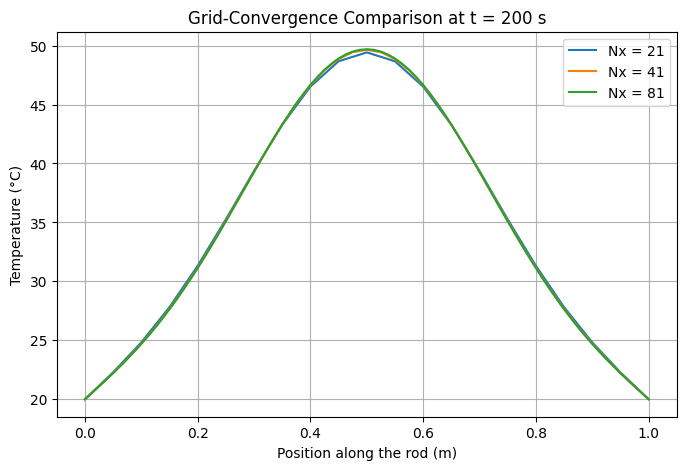

In [18]:
plt.figure(figsize=(8, 5))

for nx_test in grid_sizes:

    plt.plot(
        results[nx_test]["x"],
        results[nx_test]["T"],
        label=f"Nx = {nx_test}"
    )

plt.xlabel("Position along the rod (m)")
plt.ylabel("Temperature (°C)")
plt.title("Grid-Convergence Comparison at t = 200 s")
plt.legend()
plt.grid()
plt.show()

In [19]:
for nx_test in grid_sizes:

    T_center = results[nx_test]["T"][nx_test // 2]

    print(
        f"Nx = {nx_test:3d}  "
        f"Center temperature = {T_center:.6f} °C"
    )

Nx =  21  Center temperature = 49.422248 °C
Nx =  41  Center temperature = 49.638368 °C
Nx =  81  Center temperature = 49.691820 °C


## 14. Numerical Validation Summary

The numerical solution was evaluated using three spatial grid resolutions:

$$
N_x = 21,\ 41,\ 81
$$

The predicted center temperatures at $t=200$ s were:

$$
49.422248^\circ C,\quad
49.638368^\circ C,\quad
49.691820^\circ C
$$

The difference between the $N_x=21$ and $N_x=41$ solutions was:

$$
0.216120^\circ C
$$

while the difference between the $N_x=41$ and $N_x=81$ solutions was:

$$
0.053452^\circ C
$$

The ratio between these differences is approximately:

$$
\frac{0.216120}{0.053452}
\approx 4.04
$$

Because the spatial grid spacing is approximately halved during each refinement, a second-order numerical method is expected to reduce the discretization error by approximately a factor of four.

The observed ratio is therefore consistent with the expected second-order convergence behavior of the FTCS discretization used in this simulation.

The increasingly similar solutions provide evidence that the numerical heat solver is converging as the spatial grid is refined.